In [44]:
from keras.utils import to_categorical
from keras.preprocessing.image import load_img
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
from sklearn.preprocessing import LabelEncoder
import os
import pandas as pd
import numpy as np

In [45]:
TRAIN_DIR = "images"
TEST_DIR = "images"

In [71]:
print(train.columns)
print(test.columns)

Index(['image', 'label'], dtype='object')
Index(['image'], dtype='object')


In [46]:
def createdataframe(dir):
    image_paths = []  # Initialize the list
    labels = []       # Initialize the list
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir, label)):
            image_paths.append(os.path.join(dir, label, imagename))
            labels.append(label)
        print(label, 'completed')
    return image_paths, labels

In [47]:
train = pd.DataFrame()
train['image'], train['label'] = createdataframe(TRAIN_DIR)

0 completed
1 completed
10 completed
11 completed
12 completed
13 completed
14 completed
15 completed
16 completed
17 completed
18 completed
2 completed
3 completed
4 completed
5 completed
6 completed
7 completed
8 completed
9 completed


In [48]:
print(train)

                      image label
0        images\0\Anger.jpg     0
1     images\0\Contempt.jpg     0
2      images\0\Disgust.jpg     0
3         images\0\Fear.jpg     0
4        images\0\Happy.jpg     0
..                      ...   ...
147       images\9\Fear.jpg     9
148      images\9\Happy.jpg     9
149    images\9\Neutral.jpg     9
150        images\9\Sad.jpg     9
151  images\9\Surprised.jpg     9

[152 rows x 2 columns]


In [49]:
test = pd.DataFrame()
test['image'],train['label']=createdataframe(TRAIN_DIR)

0 completed
1 completed
10 completed
11 completed
12 completed
13 completed
14 completed
15 completed
16 completed
17 completed
18 completed
2 completed
3 completed
4 completed
5 completed
6 completed
7 completed
8 completed
9 completed


In [50]:
print(test)
print(test['image'])

                      image
0        images\0\Anger.jpg
1     images\0\Contempt.jpg
2      images\0\Disgust.jpg
3         images\0\Fear.jpg
4        images\0\Happy.jpg
..                      ...
147       images\9\Fear.jpg
148      images\9\Happy.jpg
149    images\9\Neutral.jpg
150        images\9\Sad.jpg
151  images\9\Surprised.jpg

[152 rows x 1 columns]
0          images\0\Anger.jpg
1       images\0\Contempt.jpg
2        images\0\Disgust.jpg
3           images\0\Fear.jpg
4          images\0\Happy.jpg
                ...          
147         images\9\Fear.jpg
148        images\9\Happy.jpg
149      images\9\Neutral.jpg
150          images\9\Sad.jpg
151    images\9\Surprised.jpg
Name: image, Length: 152, dtype: object


In [51]:
from tqdm.notebook import tqdm

In [52]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image, color_mode="grayscale", target_size=(48,48))
        img = np.array(img)
        features.append(img)
    features = np.array(features)
    features = features.reshape(len(features), 48, 48, 1)
    return features

In [53]:
train_features = extract_features(train['image'])

  0%|          | 0/152 [00:00<?, ?it/s]

In [54]:
test_features = extract_features(test['image'])

  0%|          | 0/152 [00:00<?, ?it/s]

In [57]:
x_train = train_features/255.0
x_test = test_features/255.0

In [74]:
print(train['label'].unique())
print(len(train['label'].unique()))

['0' '1' '10' '11' '12' '13' '14' '15' '16' '17' '18' '2' '3' '4' '5' '6'
 '7' '8' '9']
19


In [58]:
from sklearn.preprocessing import LabelEncoder

In [72]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [75]:
le.fit(train['label'])

y_train = le.transform(train['label'])

from keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=19)

In [76]:
le =LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [78]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Input(shape=(48,48,1)))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(19, activation='softmax'))

In [81]:
model.compile(optimizer = 'adam',loss = 'categorical_crossentropy', metrics= ['accuracy'])

In [83]:
predictions = model.predict(x_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step


In [84]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.0165 - loss: 2.9539 - val_accuracy: 0.0000e+00 - val_loss: 3.2402
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.0661 - loss: 2.8505 - val_accuracy: 0.0000e+00 - val_loss: 3.6621
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.0661 - loss: 2.7567 - val_accuracy: 0.0000e+00 - val_loss: 4.2284
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.0661 - loss: 2.6619 - val_accuracy: 0.0000e+00 - val_loss: 4.8463
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step - accuracy: 0.1322 - loss: 2.5628 - val_accuracy: 0.0000e+00 - val_loss: 5.4782
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step - accuracy: 0.3967 - loss: 2.4491 - val_accuracy: 0.0000e+00 - val_loss: 6.1384
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - accuracy: 0.3471 - loss: 2.3157 - val_accuracy: 0.0000e+00 - val_loss: 6.8661
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step - accuracy: 0.6198 - loss: 2.1605 -

KeyboardInterrupt: 

In [85]:
model_json= model.to_json()
with open("emotiondetector.json","w") as json_file:
     json_file.write(model_json)
model.save("emotiondetector.h5")

In [103]:
from keras.preprocessing.image import load_img
import numpy as np

def ef(image):
    img = load_img(image, color_mode='grayscale', target_size=(48,48))
    feature = np.array(img)
    feature = feature.reshape(1,48,48,1)
    feature = feature/255.0
    return feature

In [104]:
import os
print(os.path.exists('images/0/Anger.jpg'))

True


In [106]:
image = 'images/0/Anger.jpg'
print("original image is of angry")

img = ef(image)

pred = model.predict(img)
pred_index = pred.argmax()

pred_label = le.inverse_transform([pred_index])

print("Model prediction:", pred_label[0])

original image is of angry
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
Model prediction: 0


In [107]:
labels = ['angry','disgust','fear','happy','neutral','sad','surprise']

pred = model.predict(img)

print("Predicted emotion:", labels[pred.argmax()])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Predicted emotion: angry


In [108]:
image = 'images/0/Anger.jpg'

img = ef(image)

pred = model.predict(img)

pred_label = le.inverse_transform([pred.argmax()])

print("Predicted emotion:", pred_label[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Predicted emotion: 0


In [109]:
pred = model.predict(img)

pred_label = le.inverse_transform([pred.argmax()])

print("Predicted emotion:", pred_label[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
Predicted emotion: 0


In [112]:
!pip install matplotlib

In [113]:
import matplotlib.pyplot as plt
%matplotlib inline

original image is of angry
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
Model prediction: 0


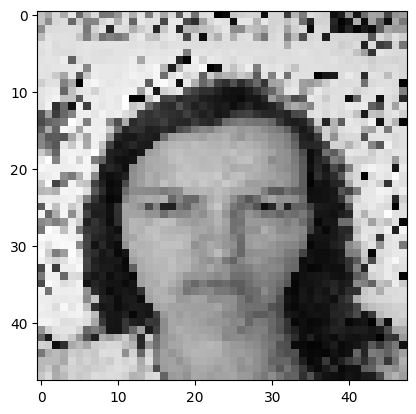

In [115]:
image = 'images/0/Anger.jpg'
print("original image is of angry")

img = ef(image)

pred = model.predict(img)
pred_index = pred.argmax()

print("Model prediction:", pred_label[0])
plt.imshow(img.reshape(48,48),cmap="gray")

original image is of sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Model prediction: 0


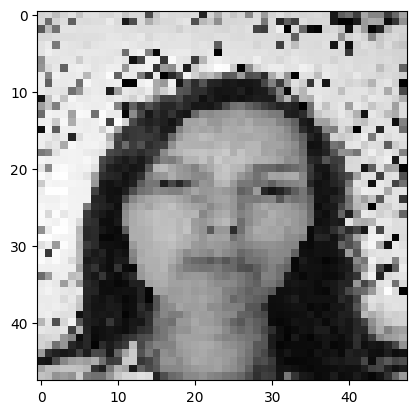

In [116]:
image = 'images/0/Sad.jpg'
print("original image is of sad")

img = ef(image)

pred = model.predict(img)
pred_index = pred.argmax()

print("Model prediction:", pred_label[0])
plt.imshow(img.reshape(48,48),cmap="gray")

original image is of happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Model prediction: 0


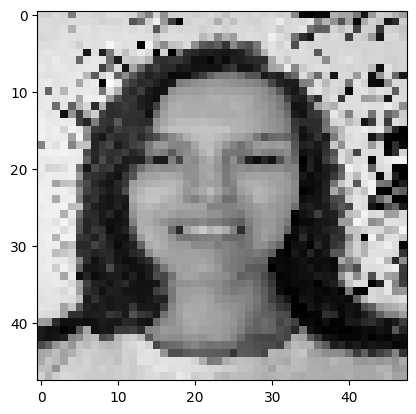

In [117]:
image = 'images/0/Happy.jpg'
print("original image is of happy")

img = ef(image)

pred = model.predict(img)
pred_index = pred.argmax()

print("Model prediction:", pred_label[0])
plt.imshow(img.reshape(48,48),cmap="gray")

original image is of fear
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Model prediction: 0


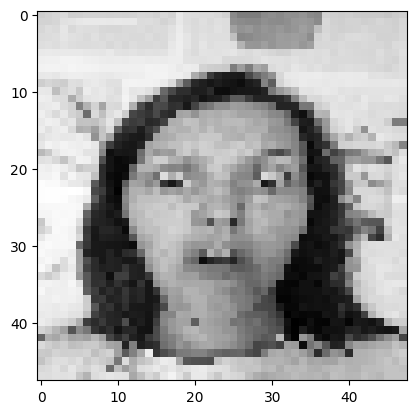

In [118]:
image = 'images/0/Fear.jpg'
print("original image is of fear")

img = ef(image)

pred = model.predict(img)
pred_index = pred.argmax()

print("Model prediction:", pred_label[0])
plt.imshow(img.reshape(48,48),cmap="gray")